## Задание 1. Геометрия данных в пространстве признаков

### 1.1 Загрузка и подготовка данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv("../data/extreme_pollution.csv", sep=";", quotechar='"')
print("Исходный размер:", df.shape)

# Выбираем числовые признаки
num_cols = ['cnt_cases', 'value_min', 'value_max']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce') # преобразуем значения в числа

# Удаляем строки с пропусками
data = df[num_cols].dropna()
print("После удаления пропусков:", data.shape)
print("Число объектов:", data.shape[0])
print("Число признаков:", data.shape[1])

data.head()

Исходный размер: (7671, 13)
После удаления пропусков: (7670, 3)
Число объектов: 7670
Число признаков: 3


,cnt_cases,value_min,value_max
0,1,6.0,6.0
1,1,60.0,60.0
2,8,71.0,100.0
3,1,60.0,60.0
4,1,9.9,9.9


### 1.2 Гистограммы распределения

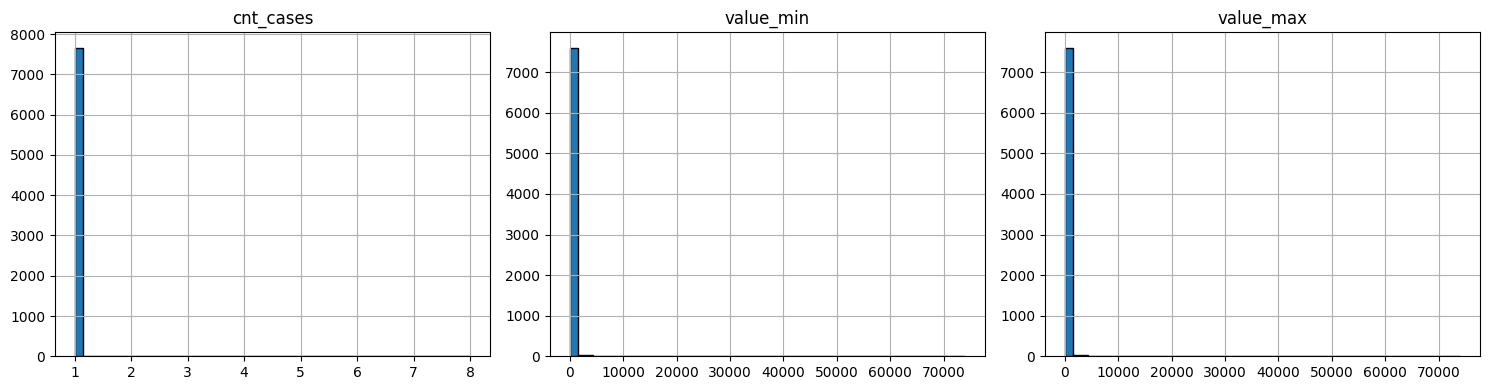

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    data[col].hist(ax=axes[i], bins=50, edgecolor='black')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 1.3 Матрица корреляций

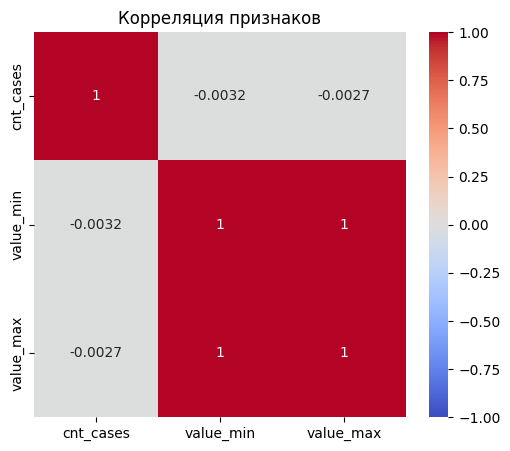

In [4]:
corr = data.corr() # парные коэффициенты корреляции Пирсона 
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Корреляция признаков')
plt.show()

##### В данных присутствуют сильно коррелированные признаки: коэффициент корреляции между value_min и value_max равен 1. 
#####    Это позволяет предположить, что один из этих признаков содержит избыточную информацию, 
##### так как они практически линейно зависимы и не добавляют новой значимой информации при совместном использовании.

## Задание 2. Реализация PCA

### 2.1 Стандартизация данных

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = data.values
print("Форма исходной матрицы:", X.shape)

# 1. Стандартизация
mean = np.mean(X, axis=0) # среднее по каждому столбцу
std = np.std(X, axis=0) # стандартное отклонение по каждому столбцу
X_scaled = (X - mean) / std

print("Средние после стандартизации:", np.mean(X_scaled, axis=0))
print("Стандартные отклонения:", np.std(X_scaled, axis=0))

Форма исходной матрицы: (7670, 3)
Средние после стандартизации: [ 3.44617859e-16  0.00000000e+00 -3.70556837e-18]
Стандартные отклонения: [1. 1. 1.]


### 2.2 Вычисление ковариационной матрицы

In [6]:
cov_matrix = np.cov(X_scaled.T)   
print("Ковариационная матрица:\n", cov_matrix)

Ковариационная матрица:
 [[ 1.0001304  -0.00317153 -0.00270174]
 [-0.00317153  1.0001304   1.00013021]
 [-0.00270174  1.00013021  1.0001304 ]]


### 2.3 Собственные значения и собственные векторы

In [7]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Собственные значения:\n", eigenvalues)
print("Собственные векторы:\n", eigenvectors)

Собственные значения:
 [1.00011326e+00 2.00027785e+00 7.40080366e-08]
Собственные векторы:
 [[-9.99991324e-01 -4.15238087e-03 -3.32156620e-04]
 [-2.70130647e-03  7.07101173e-01 -7.07107230e-01]
 [-3.17104687e-03  7.07100197e-01  7.07106255e-01]]


### 2.4 Сортировка по убыванию собственных значений

In [8]:
idx = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[idx]
eigenvectors_sorted = eigenvectors[:, idx]
print("Отсортированные собственные значения:\n", eigenvalues_sorted)

Отсортированные собственные значения:
 [2.00027785e+00 1.00011326e+00 7.40080366e-08]


### 2.5 Проекция на первые k компонент

In [9]:
k = 2
components = eigenvectors_sorted[:, :k]      # берём первые два столбца 
X_pca = X_scaled @ components                # матричное умножение
print("Размерность после PCA:", X_pca.shape)
print("Первые 5 проекций:\n", X_pca[:5])

Размерность после PCA: (7670, 2)
Первые 5 проекций:
 [[-1.79000894e-01  3.22553408e-02]
 [-9.72611349e-02  3.19159232e-02]
 [-2.59384042e-01 -4.83069036e+01]
 [-9.72611349e-02  3.19159232e-02]
 [-1.73097467e-01  3.22308273e-02]]


### 2.6 Доля объяснённой дисперсии и накопленная дисперсия

In [10]:
explained_variance = eigenvalues_sorted / np.sum(eigenvalues_sorted)
cumulative_variance = np.cumsum(explained_variance)

print("Доля объяснённой дисперсии каждой компоненты:", explained_variance)
print("Накопленная дисперсия:", cumulative_variance)

Доля объяснённой дисперсии каждой компоненты: [6.66672353e-01 3.33327622e-01 2.46661292e-08]
Накопленная дисперсия: [0.66667235 0.99999998 1.        ]


### 2.7 Графики

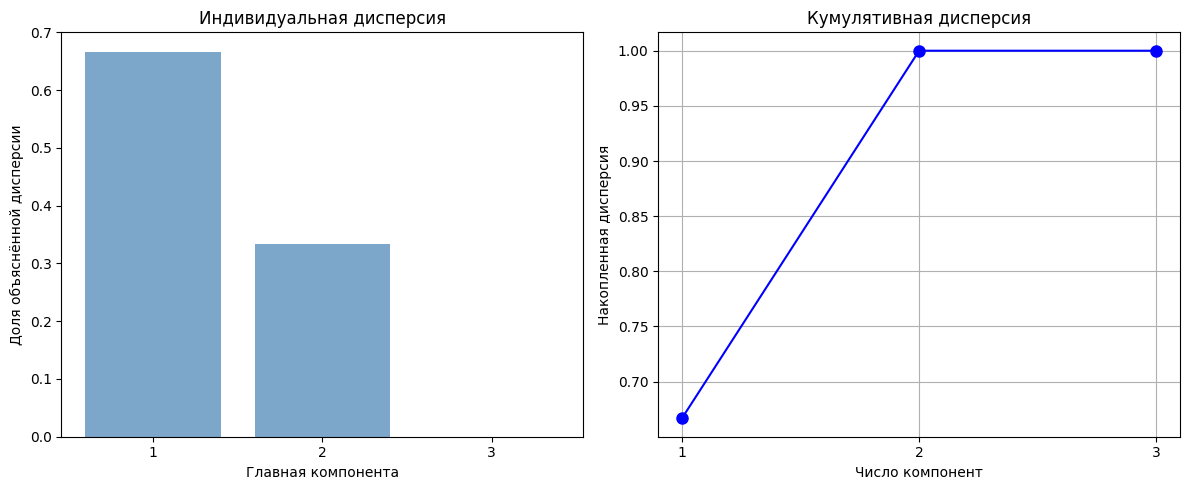

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7, color='steelblue')
plt.xlabel('Главная компонента')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Индивидуальная дисперсия')
plt.xticks(range(1, len(explained_variance)+1))

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'bo-', markersize=8)
plt.xlabel('Число компонент')
plt.ylabel('Накопленная дисперсия')
plt.title('Кумулятивная дисперсия')
plt.grid(True)
plt.xticks(range(1, len(cumulative_variance)+1))

plt.tight_layout()
plt.show()

#### Сколько компонент объясняют 80% дисперсии?
##### Две компоненты. 
##### Первая компонента объясняет только 66.67%, что недостаточно для 80%. 
##### Добавление второй компоненты даёт суммарно 100%, что превышает 80%. 
##### Необходимо для 80% дисперси - 2 компоненты.

#### Сколько компонент объясняют 95% дисперсии?
##### Две компоненты. 
##### Первая даёт 66.67%. 
##### Вместе первая и вторая дают 100%, что > 95%. 
##### Для 95% также требуется 2 компоненты.

## Задание 3. Интерпретация главных компонент

### 3.1 Коэффициенты признаков в компонентах

In [12]:
k3 = 3
components3 = eigenvectors_sorted[:, :3]
loadings = pd.DataFrame(components3.T, 
                        columns=data.columns, 
                        index=[f'PC{i+1}' for i in range(3)])
print("Коэффициенты признаков в главных компонентах:")
print(loadings)
# РС1 - уровень загрязнения, РС2 - кол-во случаев, РС3 - разница между min и max

Коэффициенты признаков в главных компонентах:
     cnt_cases  value_min  value_max
PC1  -0.004152   0.707101   0.707100
PC2  -0.999991  -0.002701  -0.003171
PC3  -0.000332  -0.707107   0.707106


### 3.2 Признаки с наибольшим вкладом

In [13]:
for i in range(3):
    comp = loadings.iloc[i]
    print(f"\nPC{i+1}:")
    print(f"  Наибольший положительный вклад: {comp.idxmax()} = {comp.max():.4f}")
    print(f"  Наибольший отрицательный вклад: {comp.idxmin()} = {comp.min():.4f}")


PC1:
  Наибольший положительный вклад: value_min = 0.7071
  Наибольший отрицательный вклад: cnt_cases = -0.0042

PC2:
  Наибольший положительный вклад: value_min = -0.0027
  Наибольший отрицательный вклад: cnt_cases = -1.0000

PC3:
  Наибольший положительный вклад: value_max = 0.7071
  Наибольший отрицательный вклад: value_min = -0.7071


#### Какие признаки больше всего влияют на первую компоненту?
##### value_min и value_max (коэффициенты ≈0.707). cnt_cases практически не влияет.

#### Можно ли интерпретировать первую компоненту как комбинацию исходных признаков?
##### Да, PC1 ≈ 0.707*value_min + 0.707*value_max - почти среднее арифметическое этих двух признаков.

#### Есть ли признаки, которые практически не влияют на первые компоненты?
##### Нет. cnt_cases сильно влияет на PC2 (коэффициент ≈ –1), а value_min и value_max - на PC1. Все три признака значимы для первых двух компонент.

### Задание 4. Визуализация данных

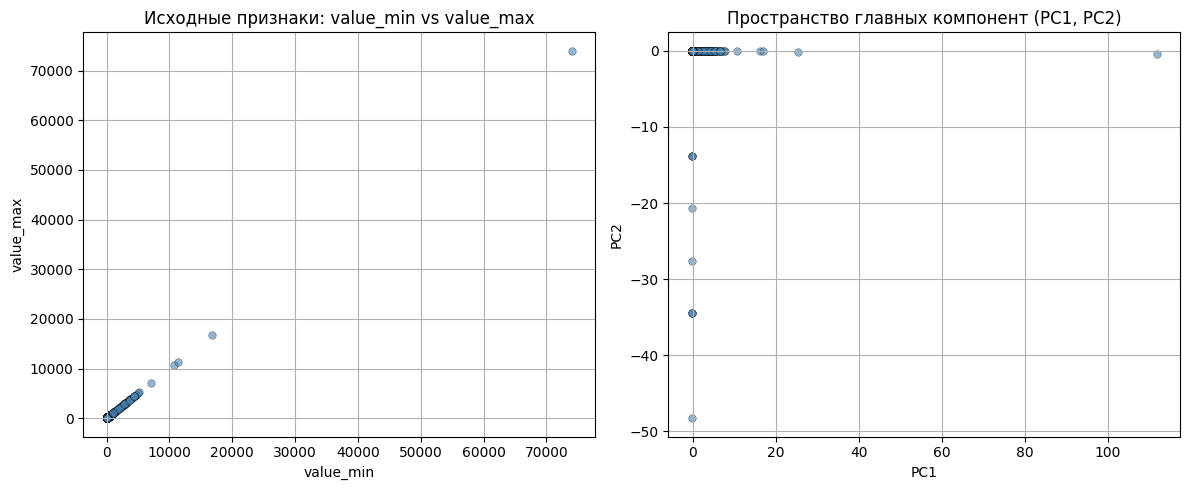

In [14]:
plt.figure(figsize=(12, 5))

# Исходные признаки: value_min, value_max
plt.subplot(1, 2, 1)
plt.scatter(data['value_min'], data['value_max'], alpha=0.6, s=30, c='steelblue', edgecolors='black', linewidth=0.3)
plt.xlabel('value_min')
plt.ylabel('value_max')
plt.title('Исходные признаки: value_min vs value_max')
plt.grid(True)

# Главные компоненты: PC1, PC2
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=30, c='steelblue', edgecolors='black', linewidth=0.3)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Пространство главных компонент (PC1, PC2)') #РС 2 - кол-во случаев, РС 1 - степень загрязнения
plt.grid(True)

plt.tight_layout()
plt.show()

#### Улучшилась ли визуализация после PCA?
##### Да. На исходном графике точки вытянуты вдоль диагонали (сильная корреляция). 
##### На графике PCA распределение стало более равномерным, и стали видны выбросы (например, точка с очень низким значением PC2).

#### Почему в пространстве главных компонент структура может быть заметнее?
##### PCA поворачивает оси в направлении максимальной дисперсии, устраняя корреляции и выделяя главные закономерности. 
##### Это позволяет увидеть выбросы, которые были скрыты из-за избыточности признаков.

## Задание 5. Нелинейные методы снижения размерности

In [ ]:
from sklearn.manifold import TSNE
import umap

# Используем X_scaled (стандартизированные данные)
X_for_tsne = X_scaled 

### 5.1 t-SNE с разными perplexity

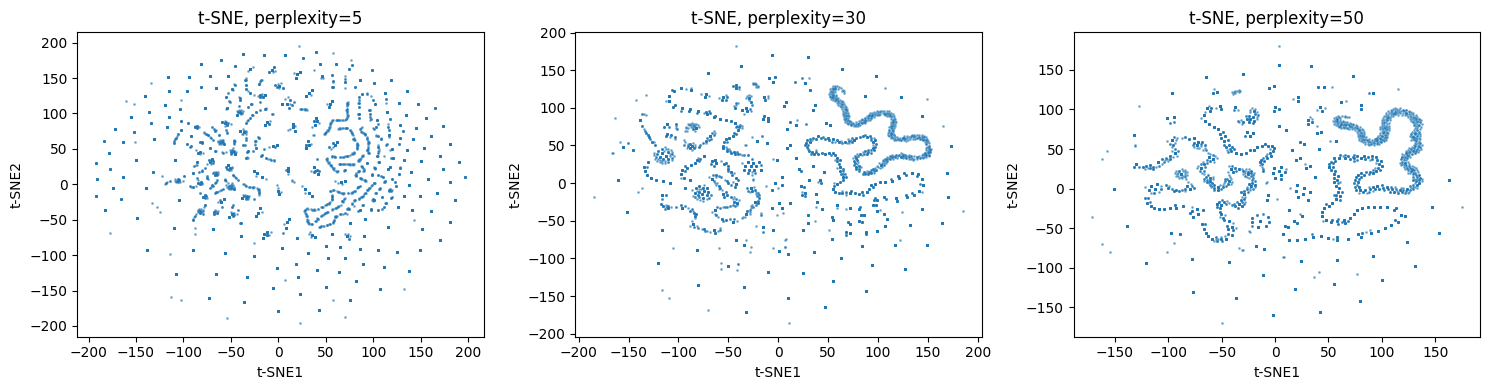

In [27]:
perplexities = [5, 30, 50]
plt.figure(figsize=(15, 4))

for i, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    X_tsne = tsne.fit_transform(X_for_tsne)
    
    plt.subplot(1, 3, i+1)
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=1, alpha=0.5)
    plt.title(f't-SNE, perplexity={perp}')
    plt.xlabel('t-SNE1')
    plt.ylabel('t-SNE2')
plt.tight_layout()
plt.show()

### 5.2 UMAP с разными параметрами

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


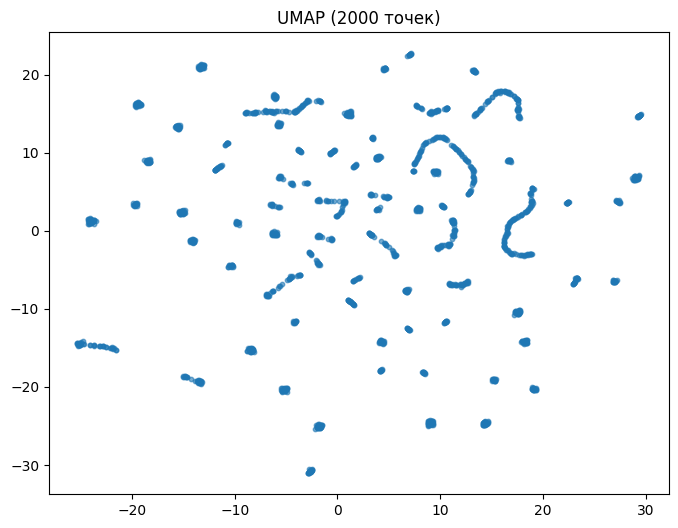

In [31]:
import numpy as np
import umap
import matplotlib.pyplot as plt

# Берём 2000 случайных точек
np.random.seed(42)
idx = np.random.choice(X_scaled.shape[0], 2000, replace=False)
X_sample = X_scaled[idx]

reducer = umap.UMAP(n_neighbors=10, min_dist=0.5, random_state=42)
X_umap = reducer.fit_transform(X_sample)

plt.figure(figsize=(8,6))
plt.scatter(X_umap[:,0], X_umap[:,1], s=10, alpha=0.6)
plt.title('UMAP (2000 точек)')
plt.show()

#### 1. Как меняется структура данных при разных параметрах?
##### t-SNE: при perplexity = 5 точки вытянуты в узкую горизонтальную линию - параметр слишком мал, структура не видна. 
##### При perplexity = 30 и 50 основная масса данных собирается в плотный центральный сгусток, а несколько точек-выбросов уходят в стороны. 
##### Чем больше perplexity, тем сильнее выбросы отрываются от основного облака.
##### UMAP: при n_neighbors = 15, min_dist = 0.1 и при n_neighbors = 10, min_dist = 0.5 точки распределены по всей плоскости равномерно, без каких‑либо компактных областей. 

#### 2. Какой метод даёт наиболее интерпретируемую визуализацию?
##### t-SNE с perplexity 30 или 50. 
##### На его графике видно, что основные данные образуют единое скопление, 
##### а аномалии (редкие случаи с высокими значениями value_min или cnt_cases > 1) хорошо изолированы. 
##### UMAP не выявил никакой структуры и дал неинтерпретируемый «шум».

#### 3. Почему результаты разных методов могут существенно отличаться?
##### t‑SNE смотрит на то, насколько точки похожи друг на друга, и старается на графике расположить похожие точки близко, а очень разные - далеко. 
##### Поэтому выбросы у него отбрасывает далеко. UMAP пытается сохранить общую форму данных и не так сильно разбрасывает выбросы, 
##### а если данные слишком простые или сильно скоррелированы, UMAP может «размазать» точки по всей плоскости

## Задание 6. Исследование степени сжатия данных

k = 1: MSE = 0.333328
k = 2: MSE = 0.000000
k = 3: MSE = 0.000000


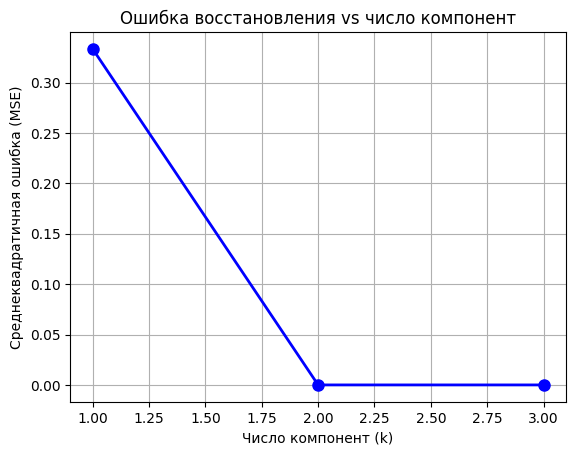

In [32]:
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Оригинальные стандартизированные данные 
X_orig = X_scaled 

k_values = [1, 2, 3]
mse_list = []

# обучаем PCA, проецируем, затем восстанавливаем обратно
for k in k_values:
    pca = PCA(n_components=k)
    X_pca = pca.fit_transform(X_orig)
    X_reconstructed = pca.inverse_transform(X_pca)
    mse = mean_squared_error(X_orig, X_reconstructed)
    mse_list.append(mse)
    print(f"k = {k}: MSE = {mse:.6f}")

# График
plt.plot(k_values, mse_list, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Число компонент (k)')
plt.ylabel('Среднеквадратичная ошибка (MSE)')
plt.title('Ошибка восстановления vs число компонент')
plt.grid(True)
plt.show()

#### 1. Почему при малом числе компонент ошибка восстановления большая?
##### Потому что одна компонента сохраняет только 66.7% дисперсии, остальные 33.3% информации теряются. Это приводит к заметной ошибке при восстановлении.

#### 2. Почему увеличение числа компонент уменьшает ошибку?
##### Каждая новая компонента добавляет недостающую информацию. При k=2 добавляется вторая компонента, которая объясняет оставшиеся 33.3% дисперсии, и восстановление становится точным (ошибка = 0).

#### 3. Можно ли полностью восстановить исходные данные при использовании всех компонент?
##### Да. При k = 3 (все компоненты) восстановление идеальное, ошибка = 0, так как PCA без потерь восстанавливает исходные данные, если оставить все компоненты.

#### 4. Как это связано с объяснённой дисперсией PCA?
##### Накопленная объяснённая дисперсия для k=1 составляла 66.7%, что соответствует доле сохранённой информации. Ошибка восстановления (MSE) равна доле потерянной дисперсии (33.3%). При k=2 накопленная дисперсия достигла 100%, поэтому ошибка стала нулевой.

#### 5. Как определить разумное число компонент, при котором данные уже хорошо описаны, но размерность существенно меньше?
##### Строят график ошибки (или накопленной дисперсии) и ищут точку, после которой ошибка перестаёт существенно уменьшаться. В нашем случае разумное число компонент – 2, потому что две компоненты дают 100% точности, а одна – слишком большая ошибка. При большем количестве признаков обычно выбирают число компонент, объясняющее 80–95% дисперсии.

## Задание 7. Итоговый анализ

#### 1. Какую роль играет снижение размерности в анализе данных?
##### Снижение размерности помогает визуализировать многомерные данные, убирать шум и избыточные признаки, ускорять работу моделей и выявлять скрытую структуру.

#### 2. Всегда ли уменьшение размерности полезно?
##### Нет. При сильном сжатии можно потерять важную информацию. Также методы типа t‑SNE и UMAP чувствительны к параметрам и могут искажать структуру.

#### 3. В каких случаях линейные методы могут работать хуже нелинейных?
##### Когда данные имеют сложную нелинейную структуру. PCA (линейный) не сможет их правильно разделить, а t‑SNE/UMAP справятся лучше.

#### 4. Преимущества и ограничения методов PCA, t‑SNE, UMAP

#### PCA
##### Плюсы: быстрый, детерминированный, легко интерпретировать компоненты.
##### Минусы: только линейный, плохо работает при нелинейных зависимостях.

#### t‑SNE
##### Плюсы: отлично показывает локальную структуру и кластеры.
##### Минусы: медленный, искажает глобальные расстояния, требует подбора perplexity.

#### UMAP
##### Плюсы: быстрее t‑SNE, лучше сохраняет глобальную структуру.
##### Минусы: чувствителен к параметрам (n_neighbors, min_dist), может давать равномерный разброс при неудачном выборе.